In [1]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from os.path import join

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir, google_folder_id, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

Added to sys: d:\GMM 4\Reading seminar\Reading-Seminar-anomaly-detection\src


In [2]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())


# Goal

The goal of this analyse is to use PCA and KPCA to detect the anomalous sessions. We will perform a global PCA on all sessions, then compare their distributions in PCA space. We can perform the clustering of the centroid, or use the Weisserstein distance. In general we will try to answer the following questions : 

- PCA and KPCA, which one is 'better' ? How to evaluate each approach ?
- How to compare the sessions ? 
    - PCA space or reconstruction
    - If PCA space, how to compare the sessions ? Centroid or distributions ?
    - Which method of clustering ?



In [3]:
import os

selected_sessions = {}
temp_list = []

for path, df in data_dict.items():
        # On extrait juste le nom du fichier
        clean_name = os.path.splitext(os.path.basename(path))[0]
        selected_sessions[clean_name] = df
        df_cleaned = preprocessing.clean_dataframe(df.copy())
        
        # C. Ajout de l'identifiant de session
        df_cleaned['session_id'] = clean_name
        
        # D. Stockage
        selected_sessions[clean_name] = df_cleaned
        temp_list.append(df_cleaned)


We concatenate all the sessions in one dataframe to help the analysis

In [4]:
df_all = pd.concat(temp_list, ignore_index=True)
display(df_all)

,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real,session_id
0,2024-04-01 22:08:14.579,0.00,0.00,0.00,0.00,-3995.51,-4000.04,-6238.11,-6171.77,6.68066,6.82229,10.16580,-0.011067,0.087145,0.000,0.000000,0.00,T24S12-04_E-AL2706
1,2024-04-01 22:08:14.589,0.00,0.00,0.00,0.00,-3997.83,-3996.56,-6238.11,-6171.77,6.64945,6.82229,10.16580,0.000813,0.087145,0.000,0.000000,0.01,T24S12-04_E-AL2706
2,2024-04-01 22:08:14.599,0.00,0.00,0.00,0.00,-3993.19,-3995.40,-6236.48,-6171.77,6.72228,6.75729,10.16580,-0.011067,0.087145,0.000,0.000000,0.02,T24S12-04_E-AL2706
3,2024-04-01 22:08:14.609,0.00,0.00,0.00,0.00,-4000.15,-4002.36,-6236.48,-6171.77,6.61824,6.68147,10.16580,0.000813,0.087145,0.000,0.000000,0.03,T24S12-04_E-AL2706
4,2024-04-01 22:08:14.619,0.00,0.00,0.00,0.00,-3992.03,-3994.24,-6236.48,-6171.77,6.67026,6.84395,10.16580,-0.011067,0.007836,0.000,0.000000,0.04,T24S12-04_E-AL2706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612460,2024-04-09 16:37:55.315,1941.59,2048.39,2035.99,2000.11,3719.91,4061.02,8024.95,7322.66,6.99120,5.85707,1.76054,-0.191725,-0.735798,251.164,0.685691,95.15,T24S12-04_E-AL3690
612461,2024-04-09 16:37:55.325,1939.69,2054.29,2030.52,2005.31,4340.05,4175.77,7702.88,9025.20,4.76465,5.60793,1.59081,-0.132327,-0.735798,251.253,1.565400,95.16,T24S12-04_E-AL3690
612462,2024-04-09 16:37:55.335,1940.64,2060.19,2031.61,2001.15,4331.93,4648.70,8151.47,9155.63,6.62705,6.68032,1.37259,-0.251123,-0.815106,251.430,-2.204790,95.17,T24S12-04_E-AL3690
612463,2024-04-09 16:37:55.345,1942.54,2050.75,2039.26,2004.27,3632.97,4354.28,8744.66,9583.57,5.14961,3.60395,1.55040,-0.227364,-0.883085,251.518,-1.356500,95.18,T24S12-04_E-AL3690


# PCA

In [5]:
df_all.columns

Index(['datetime', 'nwl1', 'nwl2', 'nwl3', 'nwl4', 'fprd1', 'fprd2', 'fprd3',
       'fprd4', 'pstr1', 'pstr3', 'astrw', 'g2', 'ny', 'vcrf', 'v2',
       'time_real', 'session_id'],
      dtype='str')

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [7]:
# Standardize the data

cols = [c for c in df_all.columns if c not in ['datetime','session_id', 'index', 'time_real']]
dfpca = df_all.copy()
dfpca['session_id'] = dfpca['session_id'].astype("category")
scaler = StandardScaler()
df_center = scaler.fit_transform(dfpca[cols])

In [8]:
# Fit the data

pca = PCA()
respca = pca.fit_transform(df_center)

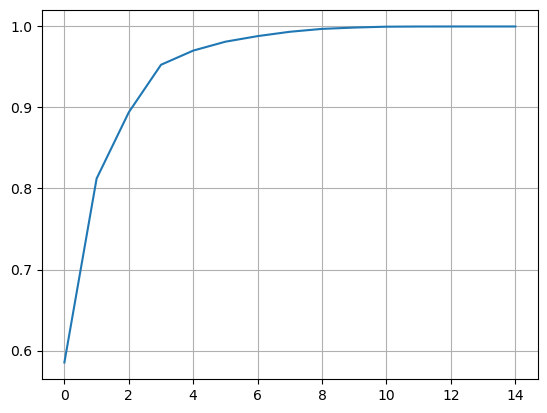

In [9]:
# Percentage of explained variance

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.grid()
plt.show()

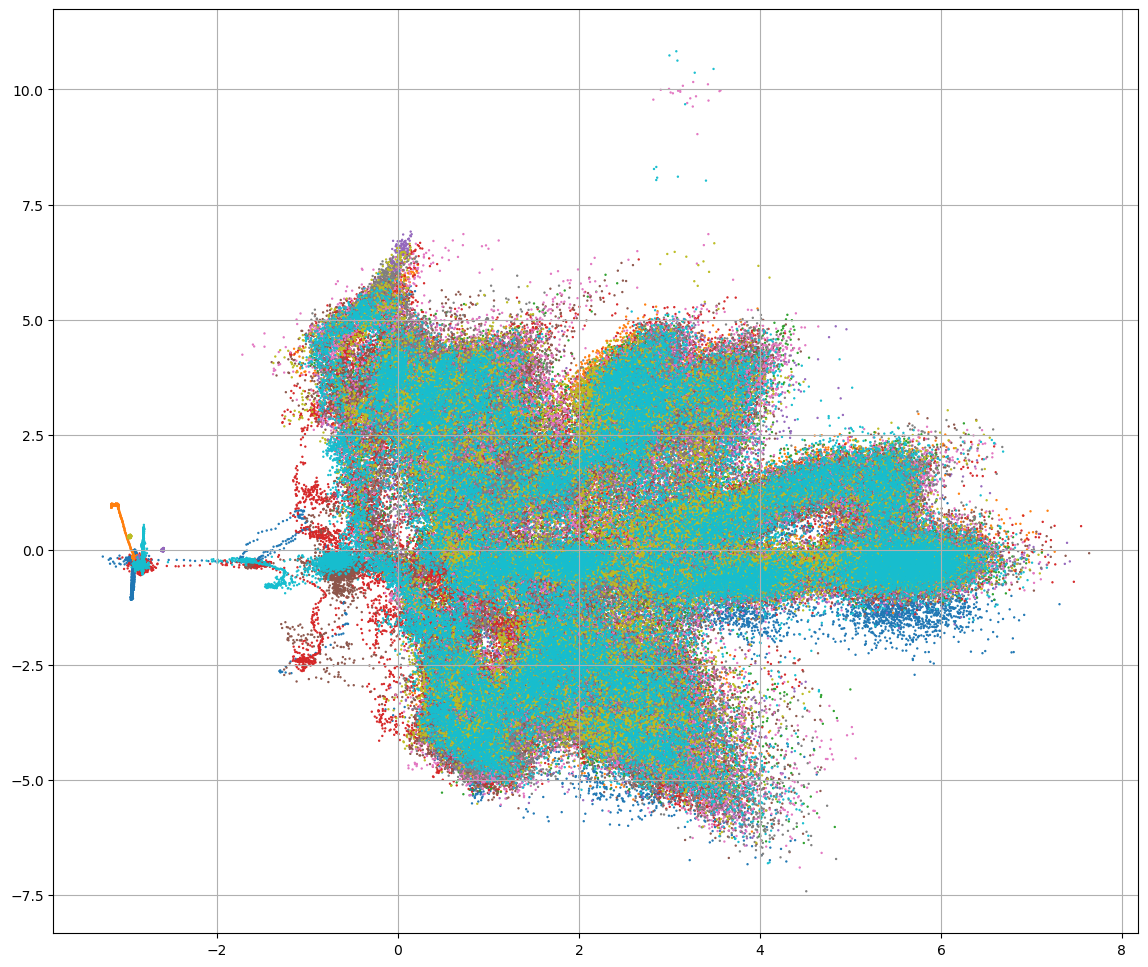

In [10]:
labels = pd.factorize(dfpca["session_id"].values)[0]
plt.figure(figsize=(14,12))
plt.scatter(respca[:,0], respca[:,1],cmap="tab10",s=0.5, c=labels)
plt.grid()
plt.show()

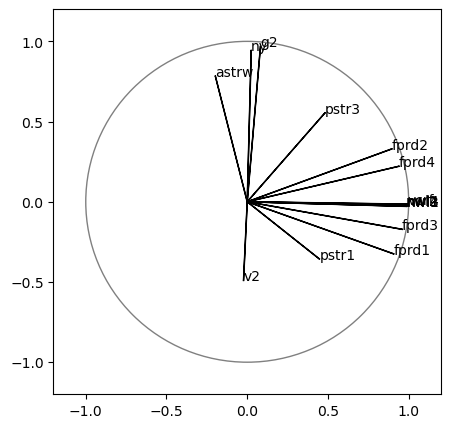

In [11]:
# Correlation circle : dim 1 and 2

coord1=pca.components_[0]*np.sqrt(pca.explained_variance_[0])
coord2=pca.components_[1]*np.sqrt(pca.explained_variance_[1])
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
for i, j, nom in zip(coord1,coord2, cols):
    plt.text(i, j, nom)
    plt.arrow(0,0,i,j,color='black')
plt.axis((-1.2,1.2,-1.2,1.2))
# cercle
c=plt.Circle((0,0), radius=1, color='gray', fill=False)
ax.add_patch(c)
plt.show()

The correlation circle is usefull when we want to detect the source of anomalies. Supposing that we know a session i is anomalous via the analysis in PCA space, we can guess which sensors have problems based on the differences on each dimension comparing to other normal sessions.

## Analysis in PCA space

Now we will detect the sessions having anomalies in PCA space, using clustering methods. Before that we need to define the "distance" between 2 samples. A naive approach is to compare the sessions using the centroid, and the distance can be euclidean distance or mahalanobis distance. A better but more complicated approach is to use [Wasserstein distance](https://en.wikipedia.org/wiki/Wasserstein_metric) which is used to calculate the distance between 2 distributions on a given metric space.

### Centroid

In [12]:
df = pd.DataFrame({
    "PC1": respca[:,0],
    "PC2": respca[:,1],
    "session": dfpca["session_id"].values
})
centroid_pca = df.groupby("session")[["PC1","PC2"]].mean()
display(centroid_pca)

,PC1,PC2
session,,
T24S12-04_E-AL2706,-2.895030,-0.149187
T24S12-04_E-AL2725,-2.702940,-0.413091
T24S12-04_E-AL2761,-2.931143,-0.320749
T24S12-04_E-AL2780,2.568499,-0.521124
T24S12-04_E-AL2819,-2.929226,-0.005540
T24S12-04_E-AL2870,2.601231,0.219357
T24S12-04_E-AL2889,2.547996,0.185511
T24S12-04_E-AL2909,2.502762,0.179134
T24S12-04_E-AL2928,2.630750,0.182966


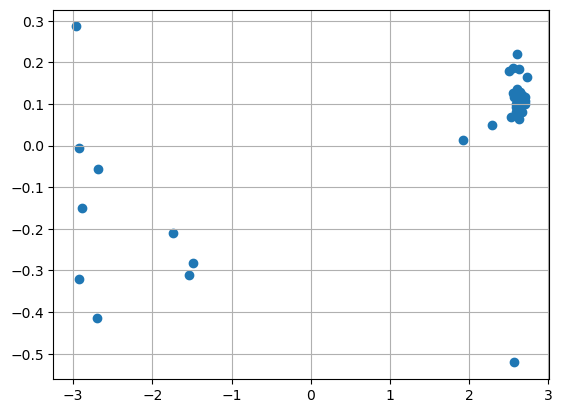

In [13]:
plt.scatter(centroid_pca["PC1"],centroid_pca["PC2"])
plt.grid()
plt.show()

In order to cluster the centroid, we will use the Agglomerative clustering which support other metric than euclidean.

C:\Users\LT-MSI\AppData\Local\Temp\ipykernel_23680\3241639832.py:12: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  cah1= sch.linkage(D1, method='complete')


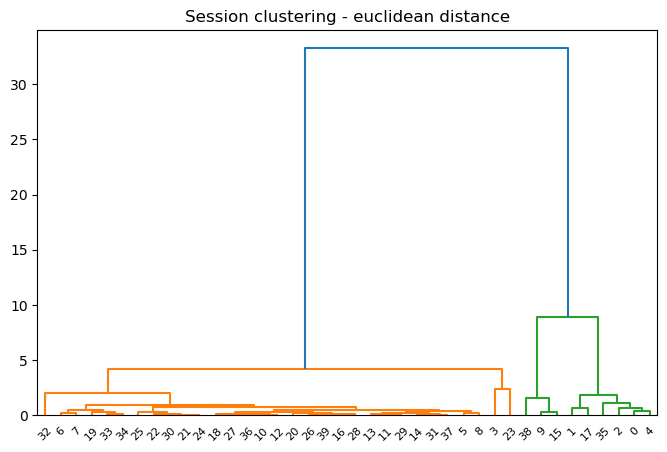

In [14]:
# CAH with euclidean distance

import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform, pdist

# Suppose D is your session x session distance DataFrame
session_names = centroid_pca.index.values
# Convert to condensed distance vector
D1 = squareform(pdist(centroid_pca.values, metric="euclidean"))

# Hierarchical clustering
cah1= sch.linkage(D1, method='complete')

plt.figure(figsize=(8,5))
sch.dendrogram(cah1)
plt.title("Session clustering - euclidean distance")
plt.show()

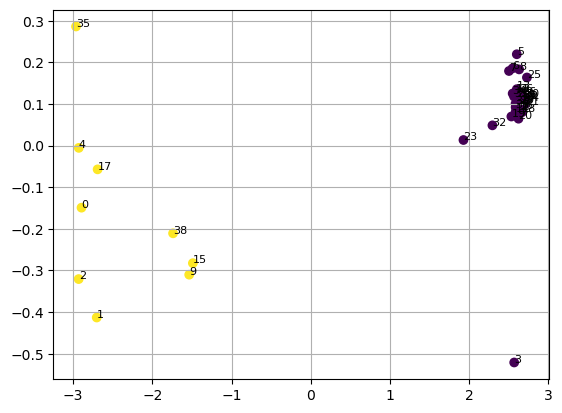

In [90]:
k = 2
labels1 = sch.fcluster(cah1, t=k, criterion="maxclust")  # cluster id for each session

# sessions per cluster
clusters1 = {}
for s, c in zip(session_names, labels1):
    clusters1.setdefault(c, []).append(s)

cluster_map1 = dict(zip(session_names, labels1))
df["cluster"] = df["session"].map(cluster_map1)

plt.scatter(centroid_pca["PC1"],centroid_pca["PC2"], c=labels1)

for i, (idx, row) in enumerate(centroid_pca.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)

plt.grid()
plt.show()

C:\Users\LT-MSI\AppData\Local\Temp\ipykernel_23680\2379029578.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  cah2= sch.linkage(D2, method='complete')


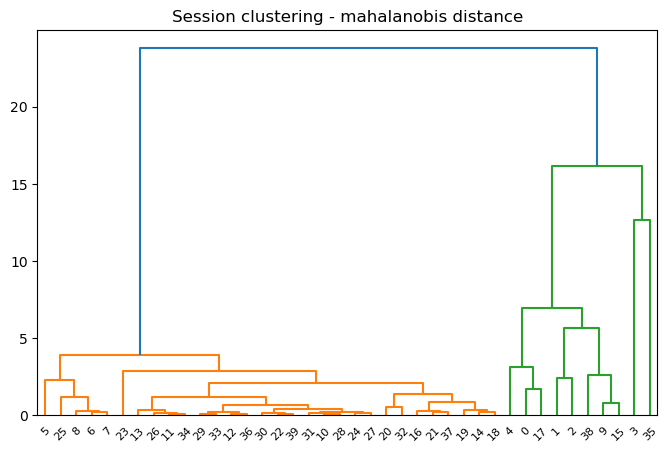

In [16]:
# Mahalanobis distance

D2 = squareform(pdist(centroid_pca.values, metric="mahalanobis"))

# Hierarchical clustering
cah2= sch.linkage(D2, method='complete')

plt.figure(figsize=(8,5))
sch.dendrogram(cah2)
plt.title("Session clustering - mahalanobis distance")
plt.show()

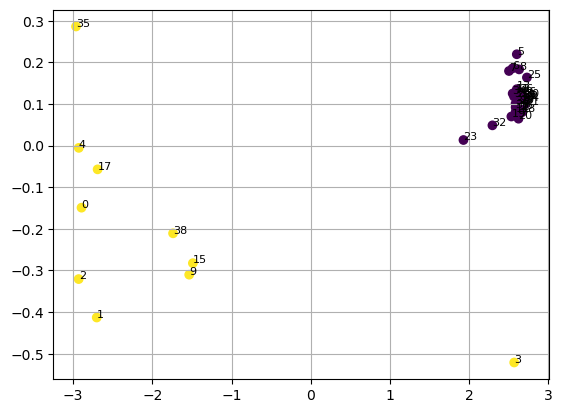

In [91]:
k = 2
labels2 = sch.fcluster(cah2, t=k, criterion="maxclust")  # cluster id for each session

# sessions per cluster
clusters2 = {}
for s, c in zip(session_names, labels2):
    clusters2.setdefault(c, []).append(s)

cluster_map2 = dict(zip(session_names, labels2))
df["cluster2"] = df["session"].map(cluster_map2)
plt.scatter(centroid_pca["PC1"],centroid_pca["PC2"], c=labels2)

for i, (idx, row) in enumerate(centroid_pca.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)

plt.grid()
plt.show()

**Comment:** 
- We can see that the final result is almost the same, except for the 3rd session having the centroid on the lower right of the graph
- There are several points which are closed to the dense cloud points. Those sessions can contain anomalies, but not as evident as others. Hence we need to do a further analysis to have the final conclusion

In [92]:
# Find the different point

error_id = list(set(clusters2[2]) - set(clusters1[2]))[0]

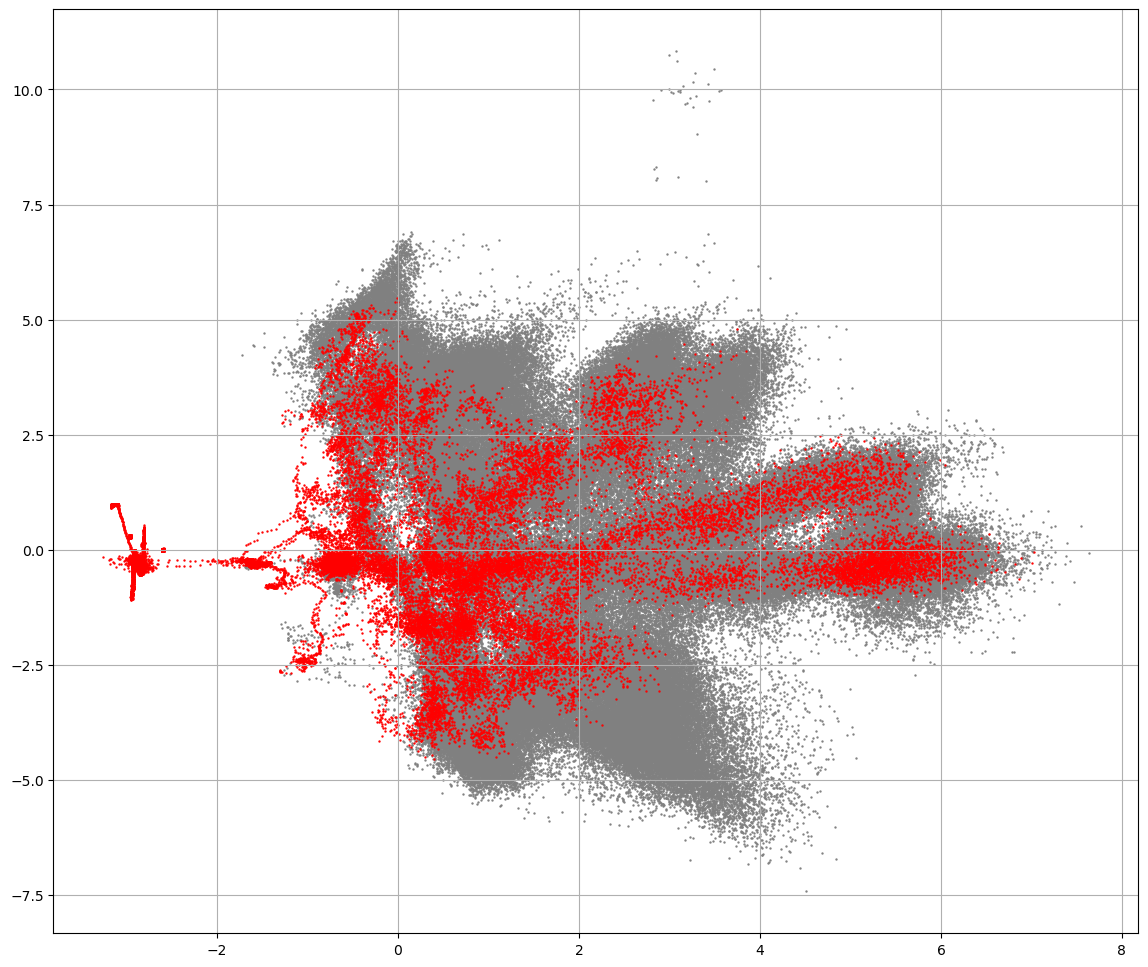

In [93]:
# PCA space, colored by cluster of CAH-euclidean

plt.figure(figsize=(14,12))
plt.scatter(df[df['cluster']==1].values[:,0], df[df['cluster']==1].values[:,1],s=0.5, c='gray')
plt.scatter(df[df['cluster']==2].values[:,0], df[df['cluster']==2].values[:,1],s=0.5, c='red')
plt.grid()
plt.show()

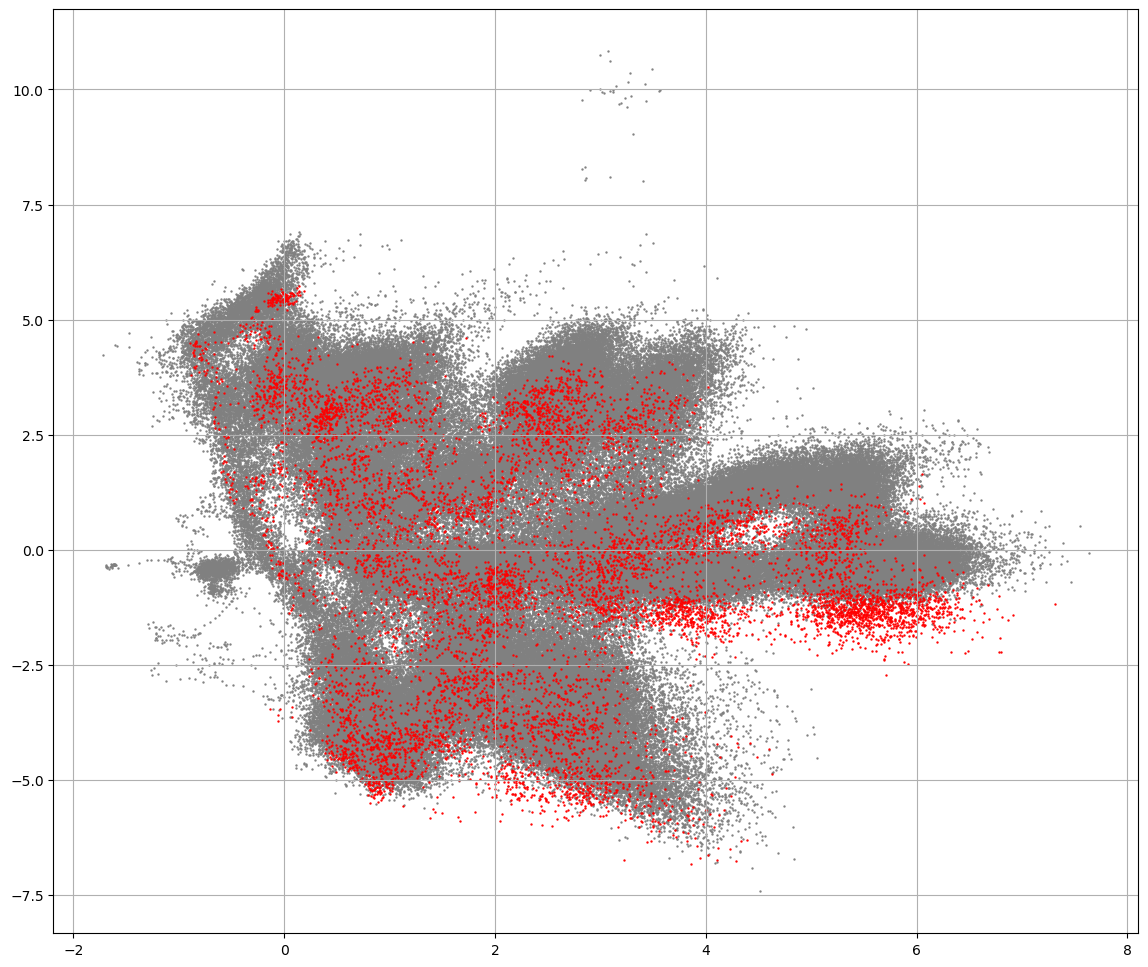

In [94]:
# projection of the 3rd session on PCA space

plt.figure(figsize=(14,12))
plt.scatter(df[df['cluster2']==1].values[:,0], df[df['cluster2']==1].values[:,1],s=0.5, c='gray')
plt.scatter(df[df["session"] == error_id].values[:,0], df[df["session"] == error_id].values[:,1],s=0.5, c='red')
plt.grid()
plt.show()

**Comments:** We know that the centroid of this session have the 1st coordinate like the cloud point, while the 2e coordinate is much lower. Hence we can deduce that the source of anomalies are related to the sensors which are highly correlated to dim2. Those variables are ny, g2, astrw, v2.

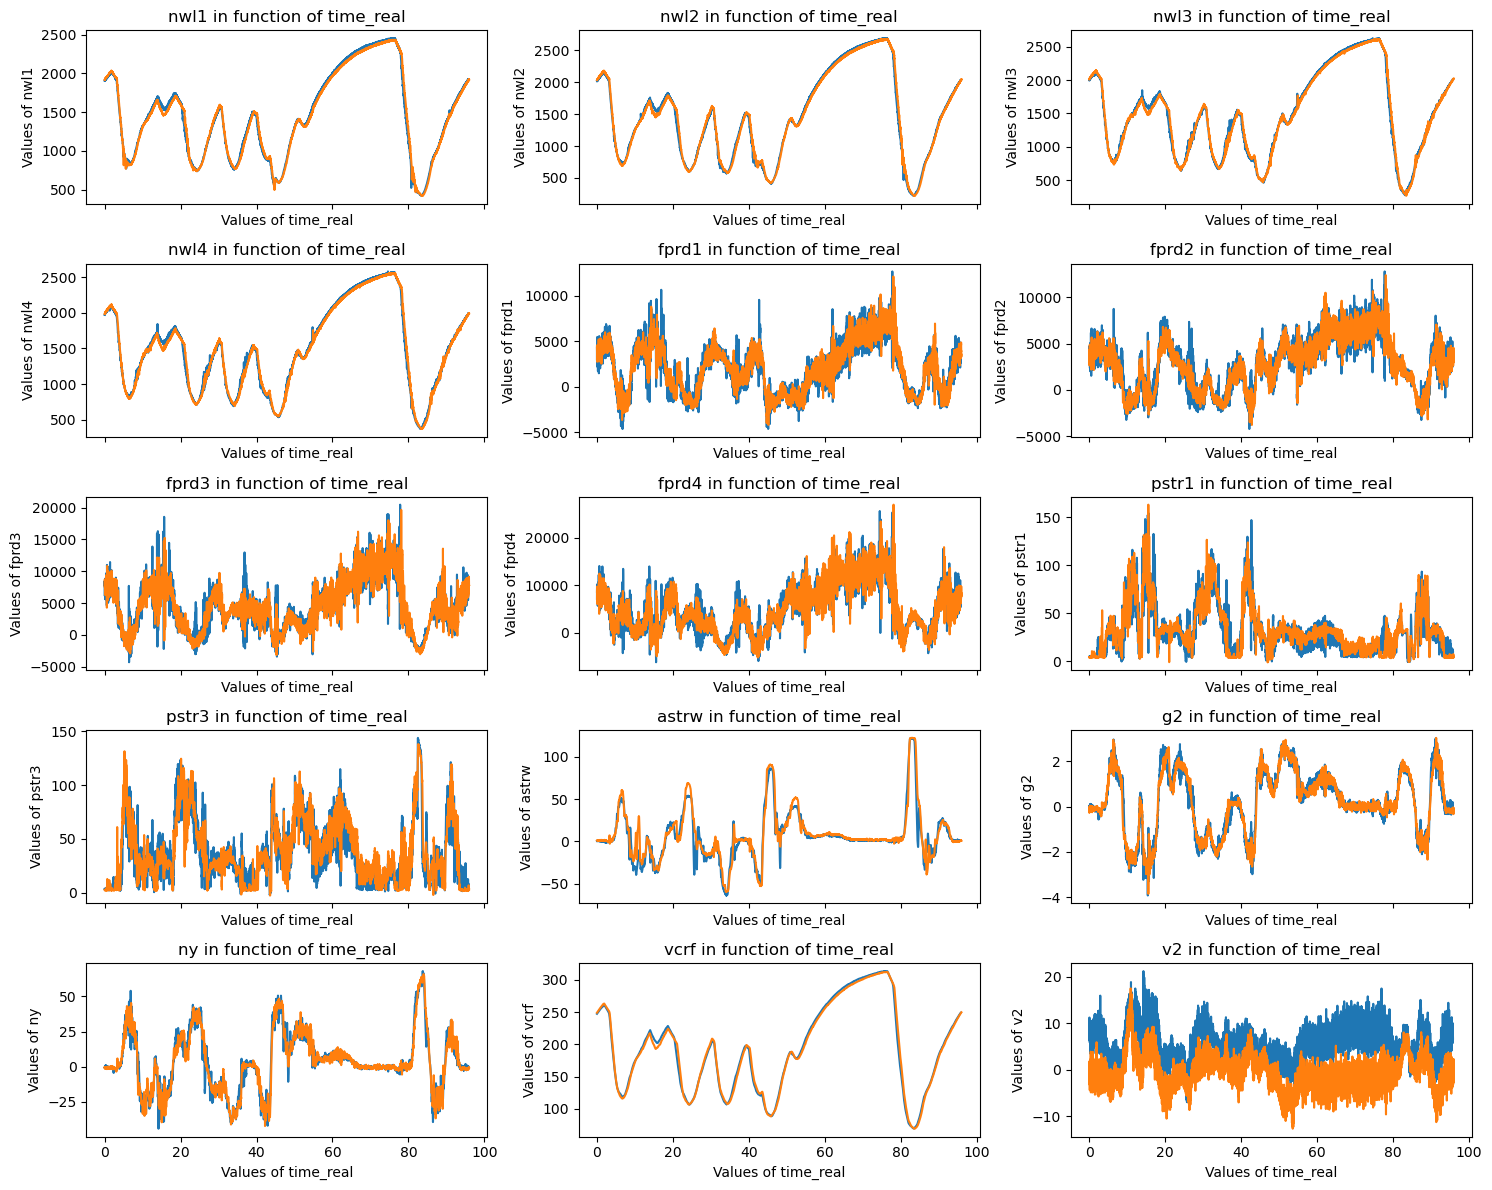

In [ ]:
# Plot of variables highly correlated to dim 2 of the 3rd session and a normal session

#id of a session in cluster 1, i.e normal session
norm_id = clusters2[1][0]

df_error = df_all[df_all["session_id"] == error_id]
df_norm = df_all[df_all["session_id"] == norm_id]

#list_cols = ["astrw", "ny", "g2", "v2"]
nrows, ncols = 5,3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols):
    visualisation.plot(df_error, 'time_real', col, ax=ax)
    visualisation.plot(df_norm, 'time_real', col, ax=ax)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

**Comments:** For this session the value of v2 sensor is higher than a normal sessions

### Distribution

Now we will use the Wasserstein distance to calculate the distance between the distribution of point. Note that the calculation is really heavy since the dataset has many points, so we will downsample the data before the calculation. For this section we need to install the package POT.

In [ ]:
import ot

dist_matrix_pca = pd.DataFrame(index=session_names, columns=session_names)

for i in range(len(session_names)):
    for j  in range(i,len(session_names)): #the distance is symmetric, so we only need to calculate half of the matrix

        X = np.asarray(df[df['session']==session_names[i]].values[:,:2],dtype="float")[::50] #Down sample the data
        Y = np.asarray(df[df['session']==session_names[j]].values[:,:2],dtype="float")[::50]
        n, m = len(X), len(Y)

        # uniform weights (each point has equal mass)
        a = np.ones(n) / n
        b = np.ones(m) / m

        # cost matrix: squared Euclidean distances between points
        M = ot.dist(X, Y, metric='euclidean')**2

        # EMD cost (W2^2 if you use squared cost)
        dist_matrix_pca.iloc[i,j] = np.sqrt(ot.emd2(a, b, M,numThreads="max"))
        dist_matrix_pca.iloc[j,i] = dist_matrix_pca.iloc[i,j]

<Axes: >

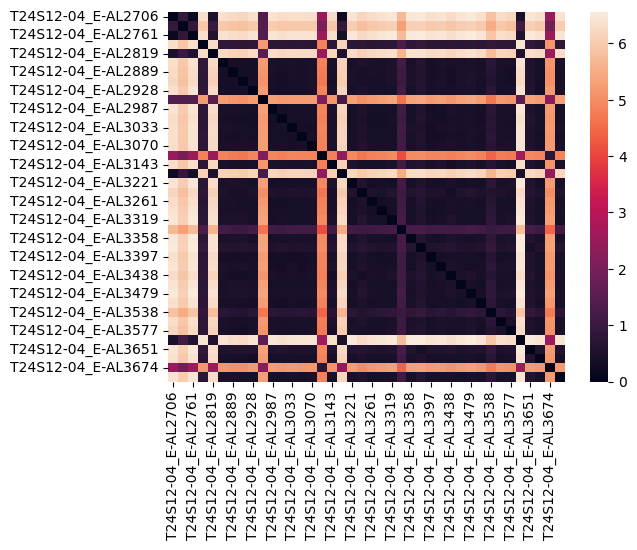

In [ ]:
# Distance matrix

import seaborn as sns
sns.heatmap(dist_matrix_pca.astype(float))

To visualize the sessions with this distance, we can use multidimensional scaling, a method to reconstruct the 2d coordinates from a distance matrix.

c:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


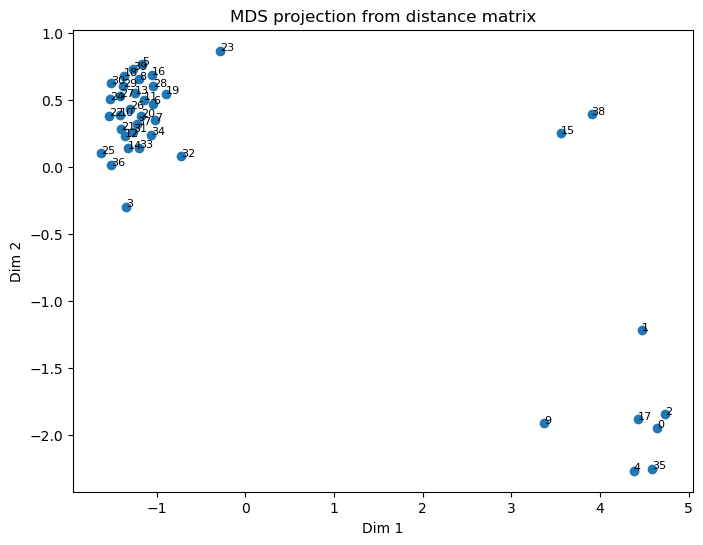

In [ ]:
from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    metric="precomputed",
    random_state=0
)

coords = mds.fit_transform(dist_matrix_pca)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1])

for i, name in enumerate(session_names):
    plt.text(coords[i, 0], coords[i, 1], str(i), fontsize=8)

plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("MDS projection from distance matrix")
plt.show()

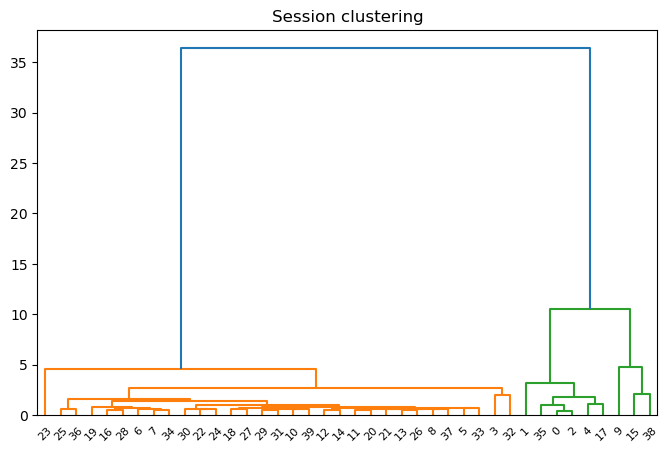

In [24]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# D = distance matrix (numpy array)
cah_pca = sch.linkage(dist_matrix_pca, method='complete')

plt.figure(figsize=(8,5))
sch.dendrogram(cah_pca)
plt.title("Session clustering")
plt.show()

In [25]:
k = 2
labels_pca = sch.fcluster(cah_pca, t=k, criterion="maxclust")  # cluster id for each session

# sessions per cluster
clusters_pca = {}
for s, c in zip(session_names, labels_pca):
    clusters_pca.setdefault(c, []).append(s)

cluster_map_pca = dict(zip(session_names, labels_pca))
df["cluster_d"] = df["session"].map(cluster_map_pca)
clusters_pca

{np.int32(2): ['T24S12-04_E-AL2706',
  'T24S12-04_E-AL2725',
  'T24S12-04_E-AL2761',
  'T24S12-04_E-AL2819',
  'T24S12-04_E-AL2948',
  'T24S12-04_E-AL3089',
  'T24S12-04_E-AL3155',
  'T24S12-04_E-AL3597',
  'T24S12-04_E-AL3674'],
 np.int32(1): ['T24S12-04_E-AL2780',
  'T24S12-04_E-AL2870',
  'T24S12-04_E-AL2889',
  'T24S12-04_E-AL2909',
  'T24S12-04_E-AL2928',
  'T24S12-04_E-AL2987',
  'T24S12-04_E-AL3014',
  'T24S12-04_E-AL3033',
  'T24S12-04_E-AL3052',
  'T24S12-04_E-AL3070',
  'T24S12-04_E-AL3143',
  'T24S12-04_E-AL3221',
  'T24S12-04_E-AL3240',
  'T24S12-04_E-AL3261',
  'T24S12-04_E-AL3280',
  'T24S12-04_E-AL3319',
  'T24S12-04_E-AL3339',
  'T24S12-04_E-AL3358',
  'T24S12-04_E-AL3377',
  'T24S12-04_E-AL3397',
  'T24S12-04_E-AL3417',
  'T24S12-04_E-AL3438',
  'T24S12-04_E-AL3458',
  'T24S12-04_E-AL3479',
  'T24S12-04_E-AL3499',
  'T24S12-04_E-AL3538',
  'T24S12-04_E-AL3558',
  'T24S12-04_E-AL3577',
  'T24S12-04_E-AL3651',
  'T24S12-04_E-AL3671',
  'T24S12-04_E-AL3690']}

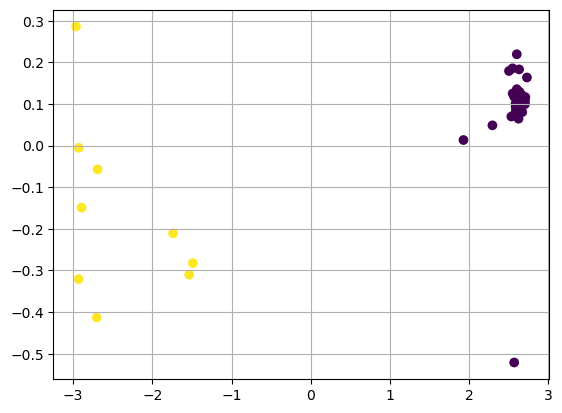

In [26]:
plt.scatter(centroid_pca["PC1"],centroid_pca["PC2"], c=labels_pca)
plt.grid()
plt.show()

**Comment:** We can detect the same anomalous sessions as using only the centroid. For the lower right session that we analyzed before, the distribution of v2 is almost the same as other normal session, except for having the slightly reduced amplitude. That is why it is still classified in the same cluster as other. However this method is more reliable since it compares the whole distribution of the sessions, which is better if we want to have a deeper analysis

In [30]:
# list of anomalous sessions, to compare with the anl01p2 data_exploration

clusters2[2]

['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

# Further analysis

In this section we will analyze the sessions in the cluster 1.

In [125]:
# List of sessions that we will analyze

list_sessions = clusters2[1]
centroid_pca2 = centroid_pca.loc[list_sessions]

In [126]:
# euclidean

De = squareform(pdist(centroid_pca2.values, metric="euclidean")) #euclidean
Dm = squareform(pdist(centroid_pca2.values, metric="mahalanobis")) #mahalanobis

idx = np.where(np.isin(session_names, list_sessions))[0]
Dw = np.asanyarray(dist_matrix_pca,dtype="float")[np.ix_(idx, idx)] #Wasserstein

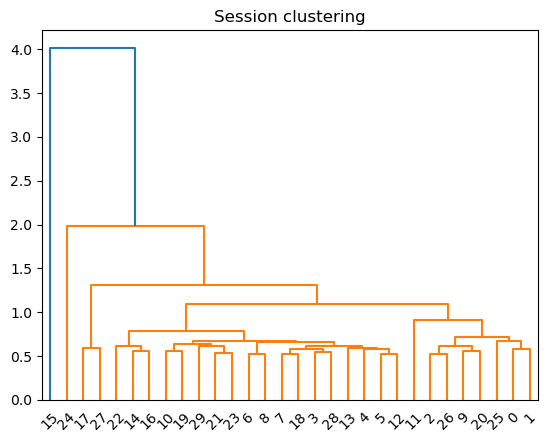

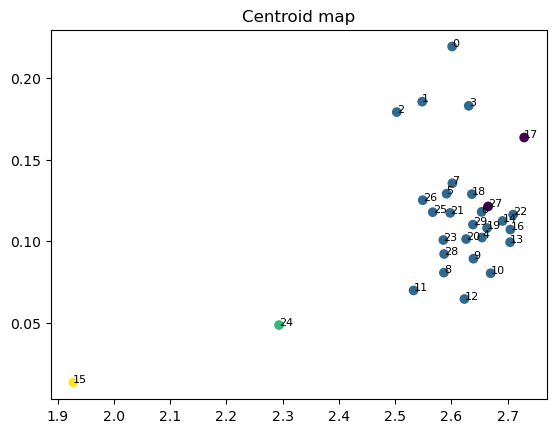

c:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


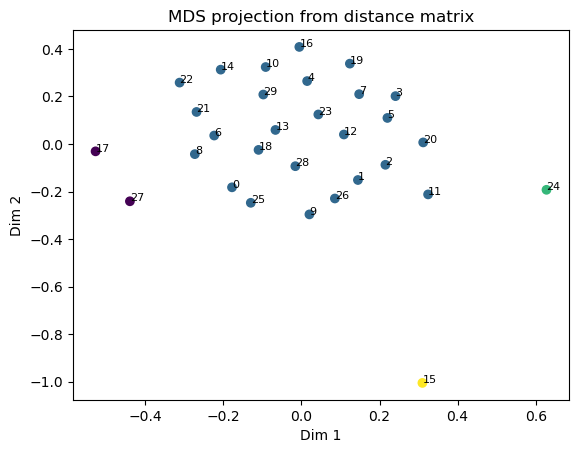

In [127]:
D = Dw
cah = sch.linkage(D, method='complete')
sch.dendrogram(cah)
plt.title("Session clustering")
plt.show()

k = 4
labels = sch.fcluster(cah, t=k, criterion="maxclust")  # cluster id for each session

# sessions per cluster
clusters = {}
for s, c in zip(list_sessions, labels):
    clusters.setdefault(c, []).append(s)

#Centroid
plt.scatter(centroid_pca2["PC1"], centroid_pca2["PC2"],c=labels)
for i, (idx, row) in enumerate(centroid_pca2.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)
plt.title("Centroid map")
plt.show()

#MDS
coords = mds.fit_transform(Dw)
plt.scatter(coords[:, 0], coords[:, 1], c=labels)
for i, name in enumerate(list_sessions):
    plt.text(coords[i, 0], coords[i, 1], str(i), fontsize=8)
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("MDS projection from distance matrix")
plt.show()

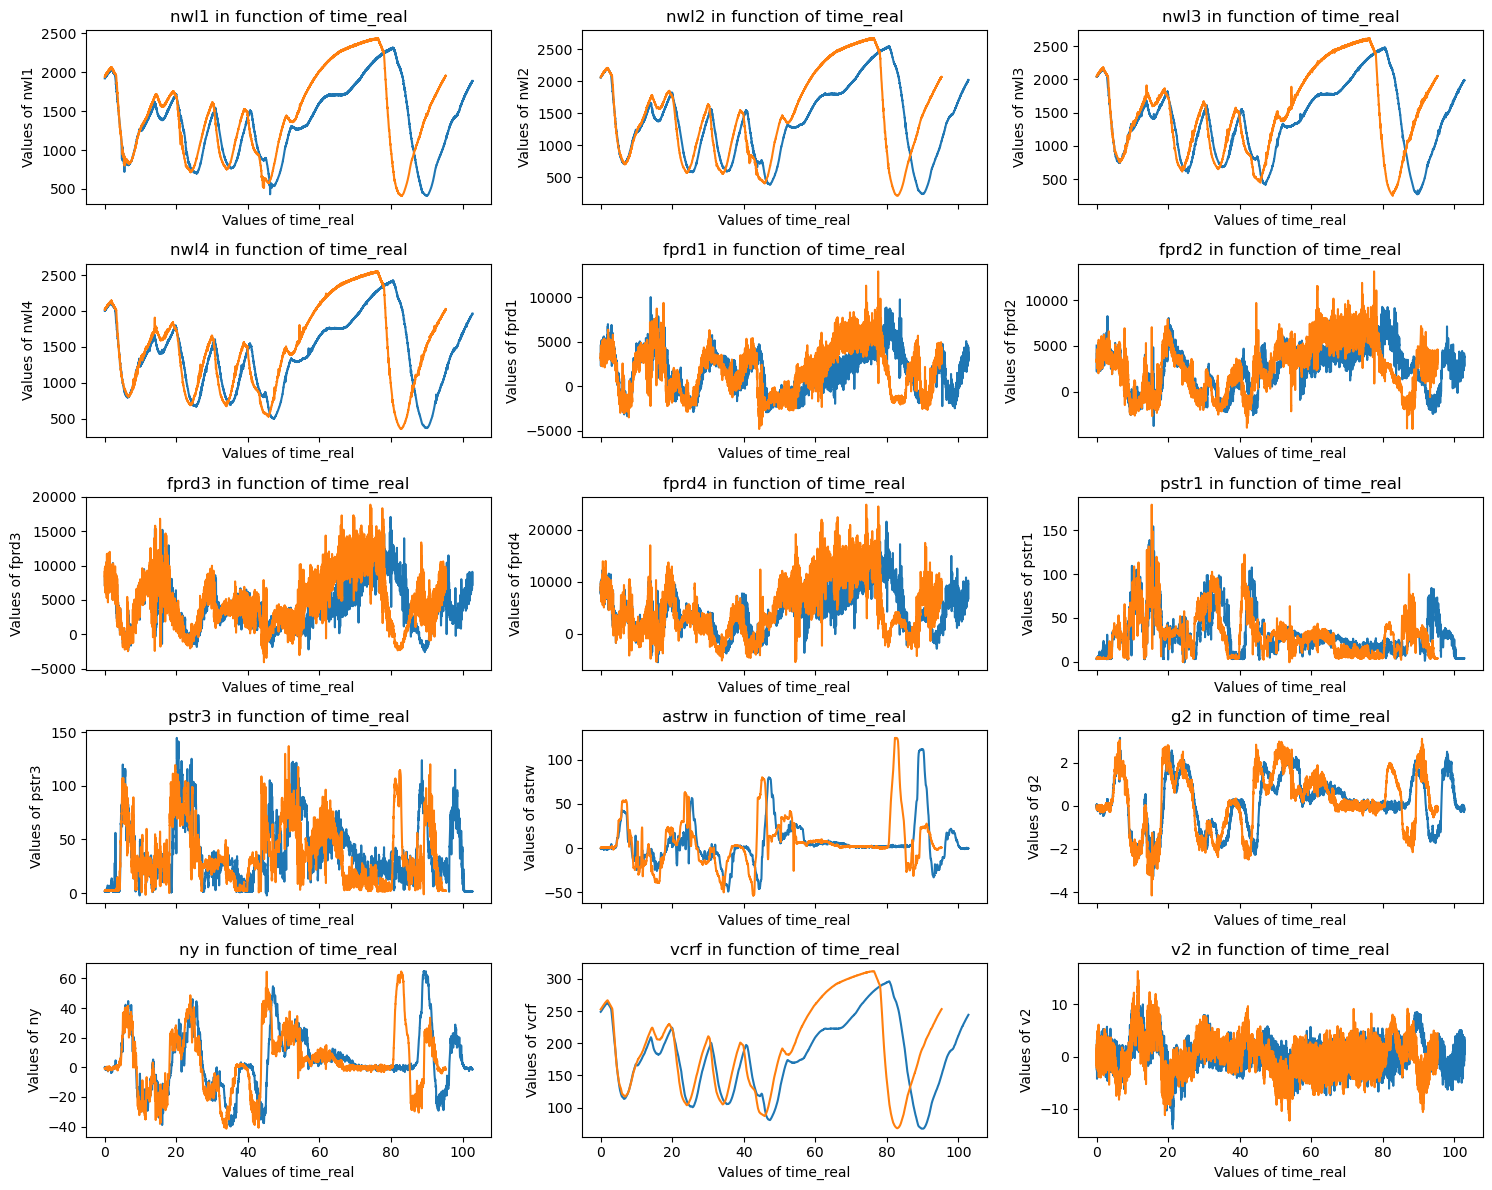

In [133]:
df_error = df_all[df_all["session_id"] == list_sessions[24]]
df_norm = df_all[df_all["session_id"] == list_sessions[23]]

#list_cols = ["astrw", "ny", "g2", "v2"]
nrows, ncols = 5,3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols):
    visualisation.plot(df_error, 'time_real', col, ax=ax)
    visualisation.plot(df_norm, 'time_real', col, ax=ax)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

**Comments:** In this case we can not conclude if the sensors are anomalous or physically correct. We need to find a way to synchronize the signals.